In [4]:
from renormalizer.tn import print_as_tree
import numpy as np

2026-06-24 10:16:57,423[INFO] Using GPU: 0
2026-06-24 10:16:57,427[INFO] Use CuPy as backend
2026-06-24 10:16:57,428[INFO] cupy random seed is 2019
2026-06-24 10:16:57,428[INFO] random seed is 1092
2026-06-24 10:16:57,483[INFO] Git Commit Hash: a938bf00dd4e0c4f2b01eeac7ddfc0ca9c60b339
2026-06-24 10:16:57,485[INFO] use 64 bits


Put into appendix

Fig6

In [2]:
import numpy as np

In [6]:
npz = np.load("Tree5.npz")
m_idx = npz["M"].tolist().index("256")
entropy = npz["entropy"][m_idx]   
node_texts = []
for s1, s2 in zip(npz["dof_strs"], entropy[-2]):
    node_texts.append(s1 + " " + str(s2)[:4])
print_as_tree(node_texts, npz["adj_matrix"])


                                                                                            ┌('F0',) 0.21
                                                                    ┌(('F1 to F4', 2),) 0.44┤
                                                                    │                       └('F1',) 0.24
                                            ┌(('F1 to F4', 1),) 0.67┤
                                            │                       │                       ┌('F2',) 0.20
                                            │                       └(('F1 to F4', 3),) 0.29┤
                                            │                                               └('F3',) 0.09
                            ┌('Vib F',) 1.44┤
                            │               │                                               ┌('F4',) 0.28
                            │               │                       ┌(('F5 to F8', 2),) 0.39┤
                            │               │                       │  

In [4]:
from matplotlib import pyplot as plt
plt.style.use("mm.mplstyle")

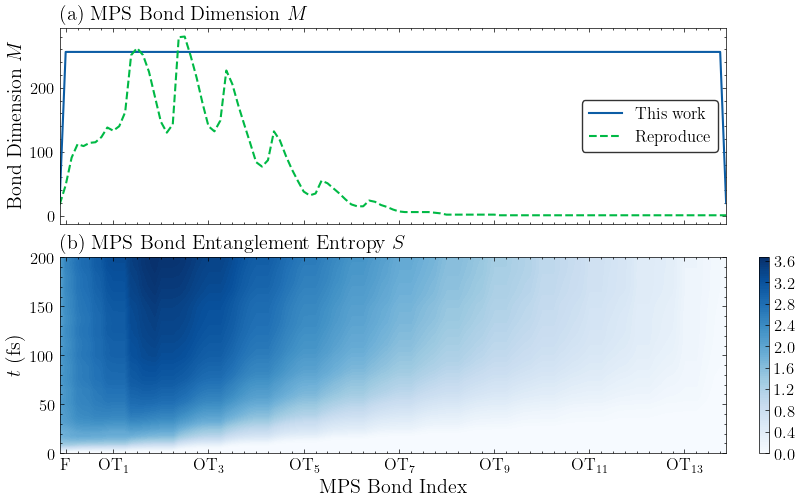

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(8, 5), layout="constrained", sharex=True)

dims1 = [18, 48, 91, 112, 109, 114, 115, 123, 138, 133, 140, 162, 251, 262, 251, 225, 186, 147, 130, 143, 279, 280, 250, 216, 176, 140, 132, 149, 227, 206, 173, 143, 114, 84, 77, 87, 132, 118, 94, 73, 55, 38, 32, 35, 55, 51, 43, 35, 26, 18, 15, 15, 24, 22, 17, 14, 10, 7, 6, 6, 6, 6, 6, 5, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
dims2 = [26] + [256] * (len(dims1) - 2) + [20]
plt.sca(axs[0])
plt.plot(dims2, label="This work")
plt.plot(dims1, label="Reproduce", linestyle="--")
plt.ylabel("Bond Dimension $M$")
plt.title("(a) MPS Bond Dimension $M$", loc="left")
plt.legend()

npz = np.load("MPS.npz")
m_idx = npz["M"].tolist().index(512)
entropy = npz["entropy"][m_idx]   

plt.sca(axs[1])
plt.contourf(entropy, cmap="Blues", levels=100)
plt.colorbar()
plt.ylabel("$t$ (fs)")
plt.xlabel("MPS Bond Index")
plt.xticks([1] + [9 + i*8 for i in range(0, 13, 2)], ["F"]+ ["OT$_{" + str(i+1) + "}$" for i in range(0, 13, 2)])
plt.title("(b) MPS Bond Entanglement Entropy $S$", loc="left")

#plt.xlim(0, len(dims1)-1)
plt.savefig("figc2.pdf")
plt.show()
